# DataBook - Sonar
Análise de dados para dados de sonar. Este notebook explora um conjunto de dados de sinais para distinguir entre rochas e minas.

## Importando Bibliotecas

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns

## Inicializando Dataset

Primeiro, arregamos o arquivo ``sonar.csv`` e fazemos um ajuste importante: convertemos as categorias de texto em números:

'R' (Rocha) -> 0

'M' (Mina) -> 1

Para uso em algoritmos de classificação.

In [26]:
replace_category = {"R": {"R": 0, "M": 1}}

df = pd.read_csv("sonar.csv")
df = df.replace(replace_category)
df

/tmp/ipykernel_564/3491156798.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(replace_category)


,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,0
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,0
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,0
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,0
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,1
203,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,1
204,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,1
205,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,1


# Tratamento dos dados
Para utilizar estratégias como KClustering e PCA é importante padronizar as features para não ter uma diferencia de peso muito grande, já que esses algoritmos usam muito da distância para conseguir categorizar.

In [27]:
X_features = df.iloc[:, :-1]
y_targets = df.iloc[:, -1].astype(int)

scaler = StandardScaler()
scaler.fit(X_features)
X_features = pd.DataFrame(scaler.transform(X_features), columns=df.columns[:-1])
X_features

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
0,0.700189,0.420421,1.052950,0.319501,0.777810,2.600518,1.522475,2.506911,1.324632,0.587392,...,-0.294569,-0.528057,-0.259343,-0.838780,0.014044,1.913786,1.084838,-0.470938,-0.442688,-0.422461
1,-0.130894,0.599427,1.719130,1.167351,0.401466,2.087862,1.967839,2.847551,3.240336,3.058831,...,-1.061350,1.012809,0.832198,-0.194293,1.227682,2.842696,4.150049,1.306561,0.252998,0.254053
2,-0.835792,-0.647546,0.480451,-0.722021,-0.983262,-1.147115,-0.190961,-0.083126,-0.996071,-0.608898,...,0.672242,-0.142840,-1.010664,0.559893,-0.112965,-0.154353,-0.482599,-0.548221,-0.636834,1.030055
3,2.044717,0.854283,0.110929,-0.315311,-0.289998,-0.671681,-0.011196,1.315846,1.516965,1.768058,...,-0.036197,-1.079853,-0.755498,-0.057168,0.239837,-1.170895,-0.099448,-0.486395,0.447143,0.572413
4,-0.026465,0.208041,-0.419933,-0.788730,-0.660939,-0.094732,-0.024152,0.571138,0.280782,0.711633,...,-0.469595,-0.934096,-1.322533,-0.975905,-1.129034,0.126073,-0.360687,-0.810982,-0.458867,-0.064306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,-0.457236,-0.116596,-0.703580,-0.782275,-0.644733,0.988106,1.315179,0.407865,0.469725,0.447527,...,0.355528,-0.194897,-0.131760,1.231805,-0.846792,0.336392,-0.221359,0.549192,1.838517,1.825954
203,0.134531,-0.859926,-0.365285,0.050513,0.016119,-0.148874,-0.365867,-0.386178,-0.630046,0.053227,...,-0.911327,-0.767516,-0.202639,0.354206,-0.423430,-0.329619,-0.761255,-0.733699,-0.280901,0.035181
204,1.000424,0.159497,-0.672353,-0.534806,-0.720362,0.211508,0.066541,-0.198238,-0.436866,0.332213,...,-0.044532,0.263199,-1.109895,-0.797643,-0.437542,0.126073,1.084838,0.904691,-0.038219,-0.681128
205,0.047506,-0.095358,0.134350,0.145196,-1.051689,0.521132,0.403398,-0.262842,0.145217,0.202020,...,-0.986338,-0.507234,-0.868905,0.230794,-0.804456,-0.820363,-0.761255,-0.007243,-0.701549,-0.342871


# Análise de Correlação
Para verificar se é possível diminuir a dimensionalidade, se mostrou interessante avaliar a correlação entre as faixas de frequência

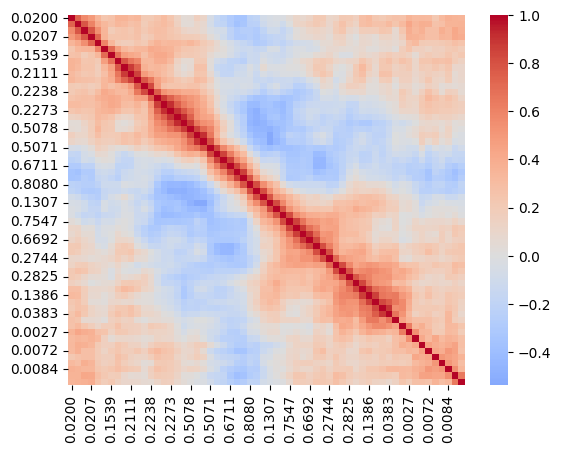

In [28]:
corr_matrix = X_features.corr()

#plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
)

plt.show()

# Avaliando as Classes
Avaliando o comportamento das respostas através dos dados de retorno no dataset sem estar normalizado, é possível observar uma distribuição e que existem pontos em que eles se sobresaem, indicando que o algoritmo não supervisionado pode achar difícil encontrar diferenças.

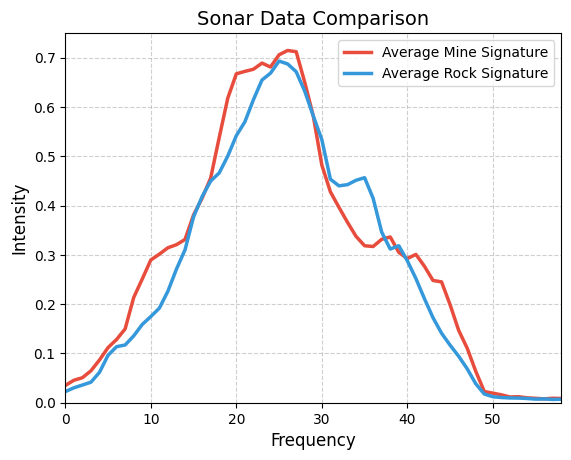

In [29]:
rocks_samples = df[df["R"] == 0].iloc[:, :-1]
mines_samples = df[df["R"] == 1].iloc[:, :-1]

temp_mines_samples = mines_samples.iloc[:, :-1].mean().reset_index().drop('index', axis=1)
temp_rocks_samples = rocks_samples.iloc[:, :-1].mean().reset_index().drop('index', axis=1)

# Plot the average signatures
plt.plot(temp_mines_samples, label='Average Mine Signature', color='#e74c3c', linewidth=2.5)
plt.plot(temp_rocks_samples, label='Average Rock Signature', color='#3498db', linewidth=2.5)
plt.legend(loc='upper right', frameon=True)
plt.title('Sonar Data Comparison', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Intensity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.margins(x=0)
plt.gca().set_ylim(0, 0.75)

plt.margins(x=0, y=0)
plt.gca().set_ylim(top=0.75)
plt.show()

In [30]:
df.columns[30]

'0.1307'

In [31]:
X_features

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
0,0.700189,0.420421,1.052950,0.319501,0.777810,2.600518,1.522475,2.506911,1.324632,0.587392,...,-0.294569,-0.528057,-0.259343,-0.838780,0.014044,1.913786,1.084838,-0.470938,-0.442688,-0.422461
1,-0.130894,0.599427,1.719130,1.167351,0.401466,2.087862,1.967839,2.847551,3.240336,3.058831,...,-1.061350,1.012809,0.832198,-0.194293,1.227682,2.842696,4.150049,1.306561,0.252998,0.254053
2,-0.835792,-0.647546,0.480451,-0.722021,-0.983262,-1.147115,-0.190961,-0.083126,-0.996071,-0.608898,...,0.672242,-0.142840,-1.010664,0.559893,-0.112965,-0.154353,-0.482599,-0.548221,-0.636834,1.030055
3,2.044717,0.854283,0.110929,-0.315311,-0.289998,-0.671681,-0.011196,1.315846,1.516965,1.768058,...,-0.036197,-1.079853,-0.755498,-0.057168,0.239837,-1.170895,-0.099448,-0.486395,0.447143,0.572413
4,-0.026465,0.208041,-0.419933,-0.788730,-0.660939,-0.094732,-0.024152,0.571138,0.280782,0.711633,...,-0.469595,-0.934096,-1.322533,-0.975905,-1.129034,0.126073,-0.360687,-0.810982,-0.458867,-0.064306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,-0.457236,-0.116596,-0.703580,-0.782275,-0.644733,0.988106,1.315179,0.407865,0.469725,0.447527,...,0.355528,-0.194897,-0.131760,1.231805,-0.846792,0.336392,-0.221359,0.549192,1.838517,1.825954
203,0.134531,-0.859926,-0.365285,0.050513,0.016119,-0.148874,-0.365867,-0.386178,-0.630046,0.053227,...,-0.911327,-0.767516,-0.202639,0.354206,-0.423430,-0.329619,-0.761255,-0.733699,-0.280901,0.035181
204,1.000424,0.159497,-0.672353,-0.534806,-0.720362,0.211508,0.066541,-0.198238,-0.436866,0.332213,...,-0.044532,0.263199,-1.109895,-0.797643,-0.437542,0.126073,1.084838,0.904691,-0.038219,-0.681128
205,0.047506,-0.095358,0.134350,0.145196,-1.051689,0.521132,0.403398,-0.262842,0.145217,0.202020,...,-0.986338,-0.507234,-0.868905,0.230794,-0.804456,-0.820363,-0.761255,-0.007243,-0.701549,-0.342871


# Redução de Dimensionalidade com PCA e treinamento utilizando KMeans


In [32]:
y_targets

,R
0,0
1,0
2,0
3,0
4,0
...,...
202,1
203,1
204,1
205,1


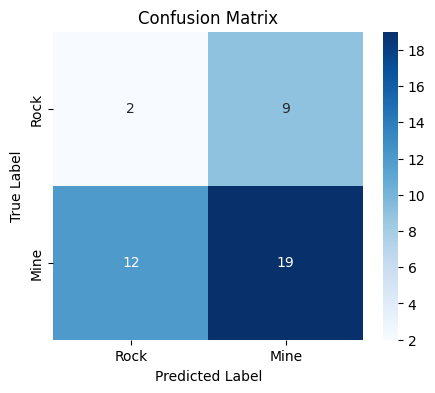

In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y_targets, test_size=0.2, random_state=53)

model = KMeans(n_clusters=2, random_state=40)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rock', 'Mine'], yticklabels=['Rock', 'Mine'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

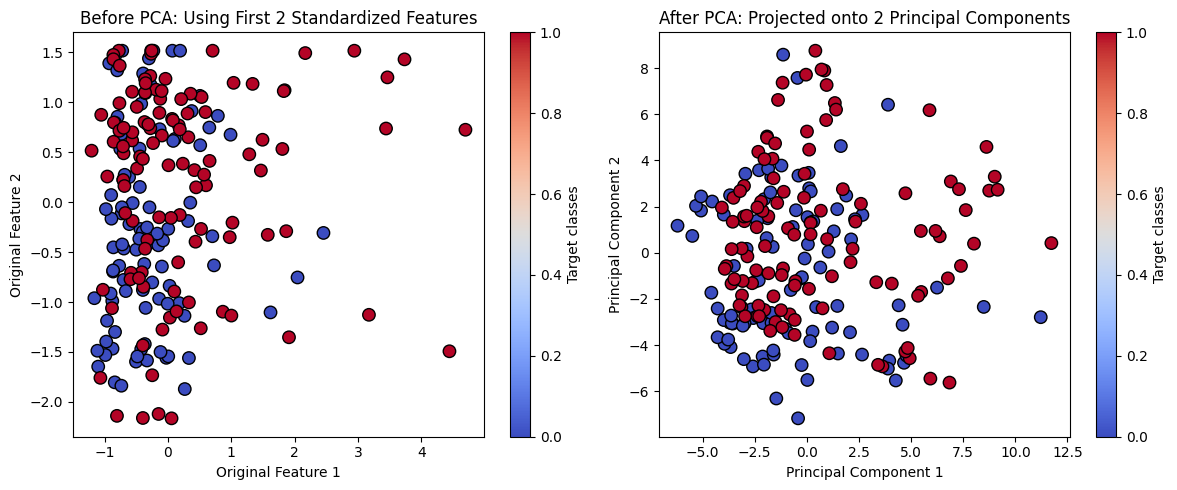

In [34]:


y_numeric = pd.factorize(y_targets)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_features.iloc[:, 0], X_features.iloc[:, 20], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()


## Observações
É possível notar que devido aos tipos de dados, a separação em clusters não foi muito boa já que, na maioria dos casos, minas e pedras não tiveram uma diferença muito grande entre si nas faixas de frequência utilizadas.

# Utilizando Redes Neurais

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

X = df.iloc[:, :-2].values.astype(np.float32)
y = df.iloc[:, -1].values.astype(np.float32)

# Split and Scale (Standardize)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)


class SonarDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1) # Reshape to (Batch, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class RandomNet(nn.Module):
    def __init__(self):
        super(RandomNet, self).__init__()
        # 60 input features -> 128 hidden -> 64 hidden -> 1 output (Binary)
        self.network = nn.Sequential(
            nn.Linear(59, 128),
            nn.ReLU(),
            nn.Dropout(0.2), # Prevents overfitting
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()     # Output between 0 and 1 for binary classification
        )

    def forward(self, x):
        return self.network(x)

# Create DataLoaders
train_ds = SonarDataset(X_train, y_train)
test_ds = SonarDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# Initialize model, loss, and optimizer
model = RandomNet()
criterion = nn.BCELoss() # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

RandomNet(
  (network): Sequential(
    (0): Linear(in_features=59, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


## Treinando Modelo

In [36]:
epochs = 500
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 10/500 | Loss: 0.5250
Epoch 20/500 | Loss: 0.3549
Epoch 30/500 | Loss: 0.2891
Epoch 40/500 | Loss: 0.2311
Epoch 50/500 | Loss: 0.1544
Epoch 60/500 | Loss: 0.1164
Epoch 70/500 | Loss: 0.1138
Epoch 80/500 | Loss: 0.0644
Epoch 90/500 | Loss: 0.0468
Epoch 100/500 | Loss: 0.0378
Epoch 110/500 | Loss: 0.0282
Epoch 120/500 | Loss: 0.0210
Epoch 130/500 | Loss: 0.0710
Epoch 140/500 | Loss: 0.0266
Epoch 150/500 | Loss: 0.0097
Epoch 160/500 | Loss: 0.0132
Epoch 170/500 | Loss: 0.0299
Epoch 180/500 | Loss: 0.0143
Epoch 190/500 | Loss: 0.0053
Epoch 200/500 | Loss: 0.0096
Epoch 210/500 | Loss: 0.0337
Epoch 220/500 | Loss: 0.0061
Epoch 230/500 | Loss: 0.0045
Epoch 240/500 | Loss: 0.0029
Epoch 250/500 | Loss: 0.0032
Epoch 260/500 | Loss: 0.0295
Epoch 270/500 | Loss: 0.0055
Epoch 280/500 | Loss: 0.0052
Epoch 290/500 | Loss: 0.0019
Epoch 300/500 | Loss: 0.0485
Epoch 310/500 | Loss: 0.0081
Epoch 320/500 | Loss: 0.0103
Epoch 330/500 | Loss: 0.0012
Epoch 340/500 | Loss: 0.0017
Epoch 350/500 | Loss: 0

## Avaliando o Modelo

In [37]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        predicted = (outputs > 0.5).float() # Threshold at 0.5
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

print(f"\nFinal Test Accuracy: {100 * correct / total:.2f}%")


Final Test Accuracy: 88.10%


In [38]:
# Data for Test Results
y_true = []
y_pred_probs = []

model.eval()
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        y_true.extend(batch_y.numpy())
        y_pred_probs.extend(outputs.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = (y_pred_probs > 0.5).astype(float)

Reports:
              precision    recall  f1-score   support

    Rock (0)       0.93      0.76      0.84        17
    Mine (1)       0.86      0.96      0.91        25

    accuracy                           0.88        42
   macro avg       0.89      0.86      0.87        42
weighted avg       0.89      0.88      0.88        42



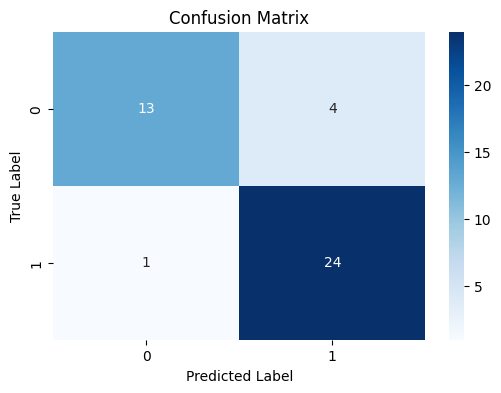

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print("Reports:")
print(classification_report(y_true, y_pred, target_names=['Rock (0)', 'Mine (1)']))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Como resultado tivemos apenas duas minas de 25 classificadas erroneamente como rochas, o que é um Recall ótimo para um sonar. Não queremos que nenhuma pessoa que utilize um sonar acabe acidentalmente colidindo com uma mina pensando que ela é uma pedra.